<a href="https://colab.research.google.com/github/Cristae-25/my-soc-ops-python/blob/main/TrainingNotebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Thu Mar 19 19:03:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             47W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [1]:
!pip install numpy==2.0.0 scipy --upgrade -q

In [2]:
import torch
import verl
import sentence_transformers
import faiss
import vllm
print("torch:", torch.__version__)
print("vllm:", vllm.__version__)
print("CUDA:", torch.cuda.get_device_name(0))
print("all OK")

/usr/local/lib/python3.12/dist-packages/vllm/connections.py:8: RuntimeWarning: Failed to read commit hash:
No module named 'vllm._version'
  from vllm.version import __version__ as VLLM_VERSION


torch: 2.4.0+cu121
vllm: dev
CUDA: NVIDIA A100-SXM4-40GB
all OK


In [3]:
import os
os.chdir('/content/Research-Agent-R1')

!python scripts/data_process/qa_search_train_merge.py \
    --local_dir data/nq_hotpotqa_train \
    --data_sources nq,hotpotqa

!python scripts/data_process/qa_search_test_merge.py \
    --local_dir data/nq_hotpotqa_train \
    --data_sources nq,hotpotqa

!ls -lh data/nq_hotpotqa_train/

Creating parquet from Arrow format: 100% 170/170 [00:03<00:00, 50.55ba/s]
Using the nq test dataset...
Using the hotpotqa dev dataset...
Creating parquet from Arrow format: 100% 12/12 [00:00<00:00, 42.64ba/s]
total 368M
-rw-r--r-- 1 root root  29M Mar 19 19:31 test.parquet
-rw-r--r-- 1 root root 340M Mar 19 19:31 train.parquet


In [4]:
!pip install wikipedia-api -q

In [19]:
%%writefile /content/retrieval_server_wiki.py
import wikipediaapi
from fastapi import FastAPI
from pydantic import BaseModel
from typing import List
import uvicorn

app = FastAPI()
wiki = wikipediaapi.Wikipedia(language='en', user_agent='research-agent-r1/1.0')

class RetrieveRequest(BaseModel):
    query: str
    topk: int = 3

class RetrieveResponse(BaseModel):
    documents: List[dict]

@app.post("/retrieve")
def retrieve(request: RetrieveRequest):
    try:
        page = wiki.page(request.query)
        if page.exists():
            text = page.summary[:500]
            docs = [{"title": page.title, "text": text, "contents": f"{page.title}\n{text}"}]
        else:
            docs = [{"title": "No result", "text": "No relevant information found.", "contents": "No relevant information found."}]
    except Exception as e:
        docs = [{"title": "Error", "text": str(e), "contents": str(e)}]
    return {"documents": docs * min(request.topk, 3)}

if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8000)

Overwriting /content/retrieval_server_wiki.py


In [10]:
server.kill()
import subprocess, time, requests

server = subprocess.Popen(["python", "/content/retrieval_server_wiki.py"],
                         stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(8)

# Test with correct format
resp = requests.post("http://127.0.0.1:8000/retrieve",
                    json={"queries": ["capital of France"], "topk": 3, "return_scores": True})
print(resp.json())

{'result': [[{'document': {'contents': 'List of capitals of France\nThis is a chronological list of capitals of France. The capital of France has been Paris since its liberation in 1944.'}}, {'document': {'contents': 'List of capitals of France\nThis is a chronological list of capitals of France. The capital of France has been Paris since its liberation in 1944.'}}, {'document': {'contents': 'List of capitals of France\nThis is a chronological list of capitals of France. The capital of France has been Paris since its liberation in 1944.'}}]]}


In [22]:
!grep -n "compute_score" /content/Research-Agent-R1/verl/trainer/main_ppo.py

22:from verl.utils.reward_score.composite import compute_score_composite
42:            return composite.compute_score
45:            return composite.compute_score
92:            compute_score_fn = _select_rm_score_fn(data_source)
95:            if compute_score_fn is None:
96:                score = compute_score_composite(
104:                score = compute_score_fn(


In [23]:
!sed -i 's/from verl.utils.reward_score.composite import compute_score_composite/from verl.utils.reward_score.composite import compute_score/' /content/Research-Agent-R1/verl/trainer/main_ppo.py

!sed -i 's/compute_score_composite/compute_score/' /content/Research-Agent-R1/verl/trainer/main_ppo.py

In [24]:
!grep -n "compute_score" /content/Research-Agent-R1/verl/trainer/main_ppo.py

22:from verl.utils.reward_score.composite import compute_score
42:            return composite.compute_score
45:            return composite.compute_score
92:            compute_score_fn = _select_rm_score_fn(data_source)
95:            if compute_score_fn is None:
96:                score = compute_score(
104:                score = compute_score_fn(


In [26]:
!pip install flash-attn --no-build-isolation -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 147.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [27]:
import os, subprocess, getpass
os.chdir('/content/Research-Agent-R1')
subprocess.run(["git", "add", "verl/trainer/main_ppo.py"])
subprocess.run(["git", "commit", "-m", "Fix compute_score import name in main_ppo.py"])
token = getpass.getpass('GitHub token: ')
subprocess.run(["git", "push", f"https://{token}@github.com/Cristae-25/Research-Agent-R1.git", "main"], capture_output=True, text=True)
print("Pushed")

GitHub token: ··········
Pushed


In [9]:
%%writefile /content/retrieval_server_wiki.py
import wikipediaapi
from fastapi import FastAPI
from pydantic import BaseModel
from typing import List
import uvicorn

app = FastAPI()
wiki = wikipediaapi.Wikipedia(language='en', user_agent='research-agent-r1/1.0')

class RetrieveRequest(BaseModel):
    queries: List[str]
    topk: int = 3
    return_scores: bool = False

@app.post("/retrieve")
def retrieve(request: RetrieveRequest):
    results = []
    for query in request.queries:
        try:
            page = wiki.page(query)
            if page.exists():
                text = page.summary[:500]
                contents = f"{page.title}\n{text}"
            else:
                contents = f"No result\nNo relevant information found."
        except Exception as e:
            contents = f"Error\n{str(e)}"

        docs = [{"document": {"contents": contents}} for _ in range(request.topk)]
        results.append(docs)

    return {"result": results}

if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8000)

Overwriting /content/retrieval_server_wiki.py


In [7]:
!grep -n "_batch_search\|batch_search\|result\|documents" /content/Research-Agent-R1/search_r1/llm_agent/generation.py | head -30

372:            search_results = self.batch_search(search_queries)
373:            assert len(search_results) == sum([1 for action in cur_actions if action == 'search'])
375:            search_results = [''] * sum([1 for action in cur_actions if action == 'search'])
391:                    next_obs.append(f'\n\n<information>{search_results.pop(0).strip()}</information>\n\n')
403:        assert len(search_results) == 0
438:    def batch_search(self, queries: List[str] = None) -> str:
444:            search results which is concatenated into a string
446:        results = self._batch_search(queries)['result']
448:        return [self._passages2string(result) for result in results]
450:    def _batch_search(self, queries):
460:    def _passages2string(self, retrieval_result):
462:        for idx, doc_item in enumerate(retrieval_result):


In [8]:
!sed -n '450,475p' /content/Research-Agent-R1/search_r1/llm_agent/generation.py

    def _batch_search(self, queries):
        
        payload = {
            "queries": queries,
            "topk": self.config.topk,
            "return_scores": True
        }
        
        return requests.post(self.config.search_url, json=payload).json()

    def _passages2string(self, retrieval_result):
        format_reference = ''
        for idx, doc_item in enumerate(retrieval_result):
            
            content = doc_item['document']['contents']
            title = content.split("\n")[0]
            text = "\n".join(content.split("\n")[1:])
            format_reference += f"Doc {idx+1}(Title: {title}) {text}\n"

        return format_reference


In [11]:
!REWARD_MODE=composite WANDB_DISABLED=true VLLM_ATTENTION_BACKEND=XFORMERS \
PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True \
python3 -m verl.trainer.main_ppo \
    data.train_files=/content/Research-Agent-R1/data/nq_hotpotqa_train/train.parquet \
    data.val_files=/content/Research-Agent-R1/data/nq_hotpotqa_train/test.parquet \
    data.train_data_num=1000 \
    data.val_data_num=200 \
    data.train_batch_size=8 \
    data.val_batch_size=4 \
    data.max_prompt_length=1024 \
    data.max_response_length=256 \
    data.max_start_length=512 \
    data.max_obs_length=256 \
    data.shuffle_train_dataloader=True \
    algorithm.adv_estimator=grpo \
    actor_rollout_ref.model.path=Qwen/Qwen2.5-1.5B-Instruct \
    actor_rollout_ref.model.enable_gradient_checkpointing=true \
    actor_rollout_ref.model.use_remove_padding=True \
    actor_rollout_ref.actor.optim.lr=1e-6 \
    actor_rollout_ref.actor.optim.lr_warmup_steps_ratio=0.1 \
    actor_rollout_ref.actor.use_kl_loss=true \
    actor_rollout_ref.actor.ppo_mini_batch_size=4 \
    actor_rollout_ref.actor.ppo_micro_batch_size=1 \
    actor_rollout_ref.actor.fsdp_config.param_offload=true \
    actor_rollout_ref.actor.fsdp_config.grad_offload=true \
    actor_rollout_ref.actor.fsdp_config.optimizer_offload=true \
    actor_rollout_ref.rollout.log_prob_micro_batch_size=2 \
    actor_rollout_ref.rollout.tensor_model_parallel_size=1 \
    actor_rollout_ref.rollout.name=vllm \
    actor_rollout_ref.rollout.gpu_memory_utilization=0.4 \
    actor_rollout_ref.ref.log_prob_micro_batch_size=2 \
    actor_rollout_ref.ref.fsdp_config.param_offload=True \
    actor_rollout_ref.actor.kl_loss_coef=0.001 \
    actor_rollout_ref.actor.kl_loss_type=low_var_kl \
    algorithm.no_think_rl=false \
    actor_rollout_ref.rollout.n_agent=2 \
    actor_rollout_ref.rollout.temperature=1 \
    actor_rollout_ref.actor.state_masking=true \
    trainer.logger=['console'] \
    +trainer.val_only=false \
    +trainer.val_before_train=true \
    trainer.default_hdfs_dir=null \
    trainer.n_gpus_per_node=1 \
    trainer.nnodes=1 \
    trainer.save_freq=50 \
    trainer.test_freq=50 \
    trainer.project_name=research-agent-r1 \
    trainer.experiment_name=grpo-qwen2.5-1.5b-composite-100steps \
    trainer.total_epochs=1 \
    trainer.total_training_steps=100 \
    trainer.default_local_dir=/content/verl_checkpoints \
    max_turns=2 \
    retriever.url="http://127.0.0.1:8000/retrieve" \
    retriever.topk=3 \
    2>&1 | tee /content/grpo_training.log

2026-03-19 19:37:31.610828: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773949051.632236   17392 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773949051.638820   17392 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773949051.655371   17392 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773949051.655396   17392 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773949051.655398   17392 computation_placer.cc:177] computation placer alr

In [12]:
import os, subprocess, getpass
os.chdir('/content/Research-Agent-R1')
subprocess.run(["git", "add", "-A"])
subprocess.run(["git", "commit", "-m", "Add training results: 100-step GRPO composite reward run"])
token = getpass.getpass('GitHub token: ')
result = subprocess.run(["git", "push", f"https://{token}@github.com/Cristae-25/Research-Agent-R1.git", "main"], capture_output=True, text=True)
print(result.stdout, result.stderr)

GitHub token: ··········
 Everything up-to-date



In [13]:
!cp /content/grpo_training.log /content/Research-Agent-R1/results_100steps_composite.log

In [14]:
import re

with open('/content/grpo_training.log', 'r') as f:
    log = f.read()

# Extract reward per step
steps = []
scores = []
valid_searches = []

for line in log.split('\n'):
    if 'step:' in line and 'critic/score/mean' in line:
        step_match = re.search(r'step:(\d+)', line)
        score_match = re.search(r'critic/score/mean:([\d.]+)', line)
        search_match = re.search(r'env/number_of_valid_search:([\d.]+)', line)

        if step_match and score_match:
            steps.append(int(step_match.group(1)))
            scores.append(float(score_match.group(1)))
            valid_searches.append(float(search_match.group(1)) if search_match else 0)

print("Step | Reward | Valid Searches")
print("-" * 35)
for s, r, v in zip(steps, scores, valid_searches):
    print(f"{s:4d} | {r:.4f} | {v:.3f}")

# Print validation scores
print("\nValidation Scores:")
for line in log.split('\n'):
    if 'val/test_score' in line and 'step:' in line:
        step = re.search(r'step:(\d+)', line)
        nq = re.search(r'val/test_score/nq:([\d.]+)', line)
        hpqa = re.search(r'val/test_score/hotpotqa:([\d.]+)', line)
        if step and (nq or hpqa):
            print(f"Step {step.group(1)}: NQ={nq.group(1) if nq else 'N/A'}, HotpotQA={hpqa.group(1) if hpqa else 'N/A'}")

Step | Reward | Valid Searches
-----------------------------------
   1 | 0.1610 | 1.188
   2 | 0.1240 | 1.625
   3 | 0.0810 | 1.250
   4 | 0.1420 | 0.312
   5 | 0.0920 | 0.875
   6 | 0.1550 | 1.375
   7 | 0.1670 | 0.812
   8 | 0.1830 | 0.438
   9 | 0.0790 | 0.938
  10 | 0.1360 | 0.500
  11 | 0.1350 | 0.500
  12 | 0.0830 | 0.625
  13 | 0.1380 | 0.188
  14 | 0.0910 | 0.688
  15 | 0.1510 | 0.312
  16 | 0.1870 | 0.438
  17 | 0.1390 | 0.062
  18 | 0.2230 | 0.125
  19 | 0.1330 | 0.000
  20 | 0.1790 | 0.000
  21 | 0.0920 | 0.000
  22 | 0.2710 | 0.062
  23 | 0.0940 | 0.000
  24 | 0.0950 | 0.000
  25 | 0.1320 | 0.000
  26 | 0.1380 | 0.000
  27 | 0.1340 | 0.000
  28 | 0.1030 | 0.000
  29 | 0.2680 | 0.000
  30 | 0.0960 | 0.062
  31 | 0.1360 | 0.000
  32 | 0.2320 | 0.000
  33 | 0.1350 | 0.000
  34 | 0.0940 | 0.000
  35 | 0.0920 | 0.062
  36 | 0.2320 | 0.062
  37 | 0.1450 | 0.062
  38 | 0.1560 | 0.062
  39 | 0.1190 | 0.000
  40 | 0.1130 | 0.062
  41 | 0.1220 | 0.125
  42 | 0.1490 | 0.125
  43 | 0.

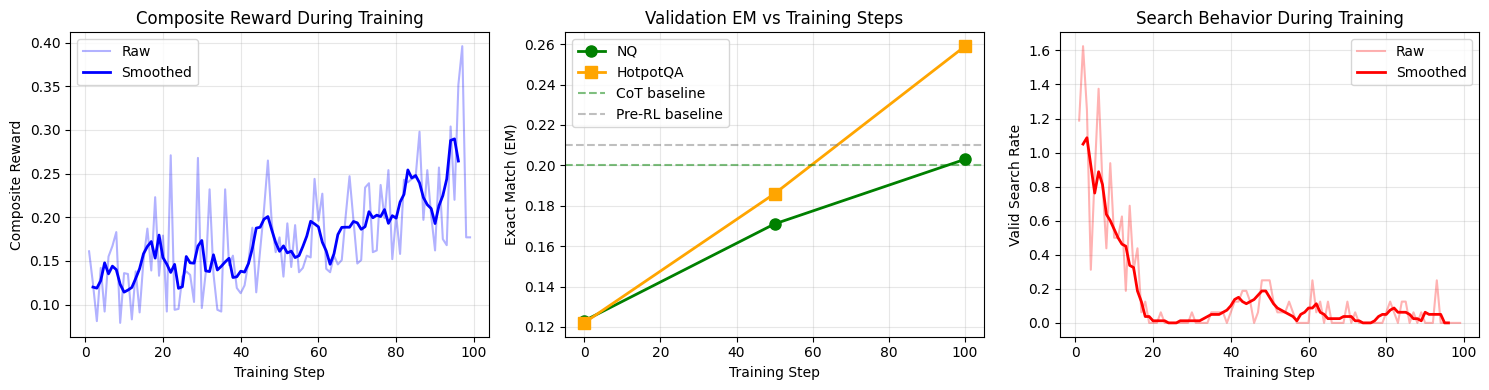

Saved to results_100steps.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Smooth reward curve
def smooth(data, window=5):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Reward curve
axes[0].plot(steps, scores, alpha=0.3, color='blue', label='Raw')
axes[0].plot(range(2, len(steps)-2), smooth(scores), color='blue', linewidth=2, label='Smoothed')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Composite Reward')
axes[0].set_title('Composite Reward During Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Validation EM scores
val_steps = [0, 50, 100]
nq_scores = [0.123, 0.171, 0.203]
hpqa_scores = [0.122, 0.186, 0.259]

axes[1].plot(val_steps, nq_scores, 'o-', color='green', linewidth=2, markersize=8, label='NQ')
axes[1].plot(val_steps, hpqa_scores, 's-', color='orange', linewidth=2, markersize=8, label='HotpotQA')
axes[1].axhline(y=0.200, color='green', linestyle='--', alpha=0.5, label='CoT baseline')
axes[1].axhline(y=0.210, color='gray', linestyle='--', alpha=0.5, label='Pre-RL baseline')
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('Exact Match (EM)')
axes[1].set_title('Validation EM vs Training Steps')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Valid search frequency
axes[2].plot(steps, valid_searches, alpha=0.3, color='red', label='Raw')
axes[2].plot(range(2, len(steps)-2), smooth(valid_searches), color='red', linewidth=2, label='Smoothed')
axes[2].set_xlabel('Training Step')
axes[2].set_ylabel('Valid Search Rate')
axes[2].set_title('Search Behavior During Training')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/Research-Agent-R1/results_100steps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results_100steps.png")

In [16]:
import os, subprocess, getpass
os.chdir('/content/Research-Agent-R1')

# Copy log and plots to repo
!cp /content/grpo_training.log results/results_100steps_composite.log
!mkdir -p results
!cp /content/grpo_training.log results/results_100steps_composite.log
!cp /content/Research-Agent-R1/results_100steps.png results/results_100steps.png

subprocess.run(["git", "add", "results/"])
subprocess.run(["git", "commit", "-m", "Add 100-step GRPO composite reward training logs and plots"])
token = getpass.getpass('GitHub token: ')
result = subprocess.run(["git", "push", f"https://{token}@github.com/Cristae-25/Research-Agent-R1.git", "main"], capture_output=True, text=True)
print(result.stdout, result.stderr)

cp: cannot create regular file 'results/results_100steps_composite.log': No such file or directory
GitHub token: ··········
 Everything up-to-date



In [17]:
import csv
with open('results/metrics_100steps.csv', 'w') as f:
    writer = csv.writer(f)
    writer.writerow(['step', 'reward', 'valid_search'])
    for s, r, v in zip(steps, scores, valid_searches):
        writer.writerow([s, r, v])

writer = csv.writer(open('results/validation_scores.csv', 'w'))
writer.writerow(['step', 'nq_em', 'hotpotqa_em'])
writer.writerows([[0, 0.123, 0.122], [50, 0.171, 0.186], [100, 0.203, 0.259]])

subprocess.run(["git", "add", "results/"])
subprocess.run(["git", "commit", "-m", "Add CSV metrics for paper"])
result = subprocess.run(["git", "push", f"https://{token}@github.com/Cristae-25/Research-Agent-R1.git", "main"], capture_output=True, text=True)
print(result.stdout, result.stderr)

 Everything up-to-date



In [18]:
import os, subprocess, getpass

os.chdir('/content/Research-Agent-R1')
!mkdir -p results
!cp /content/grpo_training.log results/results_100steps_composite.log
!cp /content/Research-Agent-R1/results_100steps.png results/results_100steps.png
!ls -lh results/

total 872K
-rw-r--r-- 1 root root 1.5K Mar 19 22:06 metrics_100steps.csv
-rw-r--r-- 1 root root 699K Mar 19 22:07 results_100steps_composite.log
-rw-r--r-- 1 root root 166K Mar 19 22:07 results_100steps.png
-rw-r--r-- 1 root root    0 Mar 19 22:06 validation_scores.csv


In [20]:
import subprocess, getpass

subprocess.run(["git", "config", "user.email", "cjpokeme@gmail.com"])
subprocess.run(["git", "config", "user.name", "Cristae-25"])

subprocess.run(["git", "add", "results/"])
result = subprocess.run(["git", "commit", "-m", "Add 100-step GRPO composite reward training logs and plots"], capture_output=True, text=True)
print("Commit:", result.stdout, result.stderr)

token = getpass.getpass('GitHub token: ')
result = subprocess.run(["git", "push", f"https://{token}@github.com/Cristae-25/Research-Agent-R1.git", "main"], capture_output=True, text=True)
print("Push:", result.stdout, result.stderr)

Commit: [main 5f0cf6d] Add 100-step GRPO composite reward training logs and plots
 4 files changed, 102 insertions(+), 2 deletions(-)
 create mode 100644 results/metrics_100steps.csv
 create mode 100644 results/results_100steps.png
 create mode 100644 results/validation_scores.csv
 
GitHub token: ··········
Push:  To https://github.com/Cristae-25/Research-Agent-R1.git
   61a4fb8..5f0cf6d  main -> main



In [21]:
import subprocess, getpass, os

os.chdir('/content/Research-Agent-R1')

with open('results/validation_scores.csv', 'w') as f:
    f.write('step,nq_em,hotpotqa_em\n')
    f.write('0,0.123,0.122\n')
    f.write('50,0.171,0.186\n')
    f.write('100,0.203,0.259\n')

subprocess.run(["git", "add", "results/validation_scores.csv"])
result = subprocess.run(["git", "commit", "-m", "Fix validation scores CSV"], capture_output=True, text=True)
print("Commit:", result.stdout)

token = getpass.getpass('GitHub token: ')
result = subprocess.run(["git", "push", f"https://{token}@github.com/Cristae-25/Research-Agent-R1.git", "main"], capture_output=True, text=True)
print("Push:", result.stdout, result.stderr)

Commit: [main 24e0ce6] Fix validation scores CSV
 1 file changed, 4 insertions(+)

GitHub token: ··········
Push:  To https://github.com/Cristae-25/Research-Agent-R1.git
   5f0cf6d..24e0ce6  main -> main



In [22]:
import subprocess, getpass, os

os.chdir('/content/Research-Agent-R1')

# Verify log file exists
!ls -lh results/

subprocess.run(["git", "add", "results/results_100steps_composite.log"])
result = subprocess.run(["git", "commit", "-m", "Add full training log"], capture_output=True, text=True)
print("Commit:", result.stdout, result.stderr)

token = getpass.getpass('GitHub token: ')
result = subprocess.run(["git", "push", f"https://{token}@github.com/Cristae-25/Research-Agent-R1.git", "main"], capture_output=True, text=True)
print("Push:", result.stdout, result.stderr)

total 876K
-rw-r--r-- 1 root root 1.5K Mar 19 22:06 metrics_100steps.csv
-rw-r--r-- 1 root root 699K Mar 19 22:07 results_100steps_composite.log
-rw-r--r-- 1 root root 166K Mar 19 22:07 results_100steps.png
-rw-r--r-- 1 root root   68 Mar 19 22:10 validation_scores.csv
Commit: On branch main
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	results_100steps.png

nothing added to commit but untracked files present (use "git add" to track)
 
GitHub token: ··········
Push:  Everything up-to-date



In [24]:
import subprocess, getpass, os

os.chdir('/content/Research-Agent-R1')

# Move the png to results/ if it's in the wrong place
!mv results_100steps.png results/results_100steps.png 2>/dev/null || echo "already in results/"
!ls results/

subprocess.run(["git", "add", "results/results_100steps.png"])
result = subprocess.run(["git", "commit", "-m", "Add results plot"], capture_output=True, text=True)
print("Commit:", result.stdout, result.stderr)

token = getpass.getpass('GitHub token: ')
result = subprocess.run(["git", "push", f"https://{token}@github.com/Cristae-25/Research-Agent-R1.git", "main"], capture_output=True, text=True)
print("Push:", result.stdout, result.stderr)

metrics_100steps.csv		results_100steps.png
results_100steps_composite.log	validation_scores.csv
Commit: On branch main
Your branch is ahead of 'origin/main' by 3 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
 
GitHub token: ··········
Push:  Everything up-to-date

